# Nome: Gabriel Delgado Panovich de Barros
# RA: 176313

# Sobre o dataset

O dataset contém imagens de diversos Pokémons, usadas para o treinamento de um modelo de autoencoder variacional.

---
> Extraído diretamente da seção **About Dataset** do dataset no *Kaggle*
## Context
I collected this dataset for my school project. The project is to train GAN to generate new Pokemon. I had a difficult time finding a training dataset that is complete and clean. So I gather this collection of images and publish it here hoping that it will help others who need a similar dataset.

You can find my project on my Github
My latest code to generate pokemon Github

## Content
819 transparent Pokemon images in png format size 256x256.

- Update August 10, 2020: 819 white background in jpg format

## Acknowledgements
I collected the image mostly from this website https://veekun.com/dex/downloads

Banner image is taken from https://viking011.deviantart.com/art/Pokemon-Poster-436455502

## Inspiration
Since I failed to generate new Pokemon with clarity (I can only generate the shape) I wish there will be others that could do it with this dataset. If you managed to, please share it!

# Objetivo do modelo de rede neural
---
Esta rede tem como função codificar as imagens dos Pokémons em um espaço latente que vai possuir propriedades úteis para classificar um Pokémon de acordo com o seu tipo principal.

Além disso, foi utililizada a API do Pokebase para criar uma tabela de labels para cada Pokémon.

# Resultados
---


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pokebase as pb
import torch

from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.transforms import Compose
from tqdm import tqdm
from typing import Tuple

# Preparação dos dados

In [2]:
EXCEPTIONS = (
    "201-f.png", "386-attack.png", "386-defense.png", "386-normal.png",
    "386-speed.png", "412-plant.png", "412-sandy.png", "412-trash.png",
    "413-plant.png", "413-trash.png", "421-overcast.png", "421-sunshine.png",
    "422-east.png", "422-west.png", "423-east.png", "423-west.png",
    "487-altered.png", "487-origin.png", "492-land.png", "492-sky.png",
    "493-normal.png", "521f.png", "550-blue-striped.png", "550-red-striped.png",
    "555-standard.png", "585-autumn.png", "585-spring.png", "585-summer.png",
    "585-winter.png", "586-autumn.png", "586-spring.png", "586-summer.png",
    "586-winter.png", "592f.png", "593f.png", "641-incarnate.png",
    "641-therian.png", "642-incarnate.png", "642-therian.png", "645-incarnate.png",
    "645-therian.png", "647-ordinary.png", "647-resolute.png", "648-pirouette.png",
    "666-elegant.png", "668f.png", "676-diamond.png", "676-heart.png",
    "676-star.png", "678f.png", "681-blade.png", "681-shield.png"
)

class CustomDB(Dataset):
    def __init__(self, labels_path: str, img_dir: str, transform: callable=None):
        """
        Args:
            labels_path: Caminho para os rótulos que geramos na função createPokemonLabels.
            img_dir: Caminho para o diretório com as imagens dos pokémons.
            transform: Transformações que fazemos nas imagens para facilitar o treinamento.
        """
        self.data = pd.read_csv(labels_path)
        self.img_dir = img_dir
        self.transform = transform

        # Esta etapa converte os tipos dos pokémons para valores numéricos, permitindo que
        # o modelo possa compreender os rótulos.
        self.classes = sorted(self.data["Type1"].unique())
        # Dicionário que usaremos para retornar do valor numérico para o tipo do pokémon
        self.classes_dic = {cls_name: i for i, cls_name in enumerate(self.classes)}
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        # --- 1. Selecionamos a imagem correspondente ---
        row = self.data.iloc[index]
        img = str(row["Filename"])
        img_path = os.path.join(self.img_dir, img)

        # --- 2. Carregamento e tratamento da imagem ---
        # Como as imagens do dataset são no formato .png, sem fundo, adicionamos um fundo.
        try:
            image = Image.open(img_path)

            if image.mode == "RGBA": # fundo transparente
                background = Image.new("RGB", image.size, (255, 255, 255))
                background.paste(image, mask=image.split()[3]) # 3 é o canal alpha
                image = background
            else:
                image = image.convert("RGB")
        except FileNotFoundError:
            print(f"Aviso: Imagem não encontrada {img_path}.")
        
        # --- 3. Carrega o label e converte para um valor numérico ---
        lbl_str = row["Type1"]
        label = self.classes_dic[lbl_str]

        # --- 4. Aplica a transformação na imagem ---
        if self.transform:
            image = self.transform(image)

        return image, label

def createPokemonLabels(img_dir: str, output_dir: str) -> None:
    """
    Cria um arquivo .csv contendo os nomes e tipos de cada pokémon. Como o dataset
    do Kaggle não possui nenhuma das duas informações, apenas o id da pokédex,
    precisamos definí-las para poder desenvolver o VAE. Além disso, alguns dos
    pokémons possuem no label da imagem certas especificações, como megaevoluções.
    Como a API do pokebase espera receber apenas o ID do pokémon, fazemos um
    tratamento desses casos especiais, ou seja, uma consulta especial. Como estamos
    fazendo inúmeras consultas à API, é de se esperar que essa função demore.

    Args:
        img_dir: Diretório do dataset de imagens.
        output_dir: Diretório de destino do .csv com os rótulos.
    """
    data = []
    files = sorted([f for f in os.listdir(img_dir) if f.endswith(".png")])

    for file in tqdm(files): # tqdm é apenas um detalhe de estética
        # try-catch para facilitar a correção de bugs, caso ocorra
        if file in EXCEPTIONS:
            continue

        try:
            # Remove a extensão do arquivo
            clean_name = os.path.splitext(file)[0] # ex: "6-mega-x" ou "25"
            pokemon_obj = None

            # LÓGICA PARA TRATAR NOMES COM HÍFEN (Megas, Alolan, etc)
            if '-' in clean_name:
                parts = clean_name.split('-', 1) # Divide apenas no primeiro hífen
                base_id = parts[0]    # "6"
                suffix = parts[1]     # "mega-x"
            
                try:
                    # --- 1. Descobrir o nome do Pokémon base pelo ID ---
                    base_name = pb.pokemon(int(base_id)).name
                
                    # --- 2. Montar o nome que a API espera (charizard-mega-x) ---
                    api_full_name = f"{base_name}-{suffix}"
                
                    # --- 3. Buscar os dados da forma específica ---
                    pokemon_obj = pb.pokemon(api_full_name)
                
                except:
                    # Fallback: Se falhar (ex: nome da imagem não bate com a API), 
                    # tenta pegar só o tipo do Pokémon base para não perder a imagem
                    pokemon_obj = pb.pokemon(int(base_id))
                    print(f"Aviso: Usando tipo base para {clean_name}")

            else:
                # Caso padrão: apenas número
                pokemon_obj = pb.pokemon(int(clean_name))

            # Extrair o Tipo Primário
            if pokemon_obj:
                primary_type = pokemon_obj.types[0].type.name
            
                data.append({
                    'Filename': file,
                    'Name': pokemon_obj.name,
                    'Type1': primary_type
                })
            
        except Exception as e:
            print(f"Erro crítico ao processar {file}: {e}")

    df = pd.DataFrame(data)
    df.to_csv(output_dir, index=False)
    print(df['Type1'].value_counts()) # Mostra quantos de cada tipo encontrou

def loadData(label_path: str,
             img_path: str,
             transformation: callable,
             batch_size: int = 32) -> Tuple[DataLoader, DataLoader]:
    """
    Carrega os dados em formato de um DataLoader customizado.

    Args:
        label_path: Caminho para o arquivo .csv que contém os rótulos.
        img_path: Diretório que armazena as imagens.
        transformation: Transformação que redimenziona a imagem e converte para um tensor.
        batch_size: Tamanho dos lotes de treinamento.

    Output:

    """
    # --- 1. Montagem do dataset ---
    dataset = CustomDB(label_path, img_path, transformation)

    # --- 2. Separação dos conjuntos ---
    full_size = len(dataset)
    train_size = int(0.8 * full_size)
    val_size = int(0.1 * full_size)
    test_size = full_size - train_size - val_size
    train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

    # --- 3. Criação dos DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0 # colocar em 2 no Colab, caso identifique algum erro
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False, # não precisamos embaralhar
        num_workers=0 # colocar em 2 no Colab, caso identifique algum erro
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0 # colocar em 2 no Colab, caso identifique algum erro
    )

    return train_loader, val_loader, test_loader

# Funções de visualização do espaço latente

In [ ]:
def visualize_latent_space_pca(latent_vectors, labels, class_names):
    """
    Aplica PCA para reduzir o espaço latente para 2D e plota os clusters.
    
    Args:
        latent_vectors: Array numpy com dimensão (N_amostras, Latent_Dim)
        labels: Array numpy com os índices das classes (0, 1, 2...)
        class_names: Lista ou Dicionário mapeando índice -> Nome (ex: 'Fire', 'Water')
    """
    # --- 1. Aplica PCA para reduzir para 2 componentes (2D) ---
    pca = PCA(n_components=2)
    latent_2d = pca.fit_transform(latent_vectors)
    
    # Quanto da variância é explicada
    explained_variance = pca.explained_variance_ratio_
    print(f"Variância explicada por PC1: {explained_variance[0]:.2%}")
    print(f"Variância explicada por PC2: {explained_variance[1]:.2%}")
    print(f"Total: {sum(explained_variance):.2%}")

    # --- 2. Plotagem ---
    plt.figure(figsize=(10, 8))
    
    # Usamos um colormap que suporte muitas classes (tab20 é bom para até 20 tipos)
    scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], 
                          c=labels, cmap='tab20', alpha=0.7, s=15)
    
    plt.colorbar(scatter, label="Classes (Índices)")
    plt.title(f"Projeção PCA do Espaço Latente (Total Var: {sum(explained_variance):.1%})")
    plt.xlabel(f"Principal Component 1 ({explained_variance[0]:.1%})")
    plt.ylabel(f"Principal Component 2 ({explained_variance[1]:.1%})")
    
    # Tentar criar uma legenda com nomes reais (pode ficar poluído se forem muitos)
    if class_names:
        # Lógica simplificada para printar quais índices são quais tipos no console
        print("\nLegenda de Classes:")
        for idx, name in enumerate(class_names):
            print(f"{idx}: {name}")

    plt.grid(True, alpha=0.3)
    plt.show()

def visualize_latent_space_tsne(latent_vectors, labels, class_names):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    latent_2d = tsne.fit_transform(latent_vectors)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap='tab20', alpha=0.7, s=15)
    plt.colorbar(scatter, label="Classes")
    plt.title("Visualização t-SNE do Espaço Latente")

    if class_names:
        # Lógica simplificada para printar quais índices são quais tipos no console
        print("\nLegenda de Classes:")
        for idx, name in enumerate(class_names):
            print(f"{idx}: {name}")

    plt.grid(True, alpha=0.3)
    plt.show()

# Classe de VAE e funções de treino, validação e teste

In [4]:
class VAEmodel(nn.Module):
    """ Modelo extraído de um exemplo do Kaggle, com adaptações """
    def __init__(self, latent_dims, hidden_dims, image_shape):
        super(VAEmodel, self).__init__()
        
        self.latent_dims = latent_dims # Size of the latent space layer
        self.hidden_dims = hidden_dims # List of hidden layers number of filters/channels
        self.image_shape = image_shape # Input image shape
        
        self.last_channels = self.hidden_dims[-1]
        self.in_channels = self.image_shape[0]
        # Simple formula to get the number of neurons after the last convolution layer is flattened
        self.flattened_channels = int(self.last_channels*(self.image_shape[1]/(2**len(self.hidden_dims)))**2) 
       
        # --- 1. Codificador (Encoder) ---
        # For each hidden layer we will create a Convolution Block
        modules = []
        for h_dim in self.hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(in_channels=self.in_channels,
                              out_channels=h_dim,
                              kernel_size=3,
                              stride=2,
                              padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.ReLU()
                )
            )
            
            self.in_channels = h_dim
        
        self.encoder = nn.Sequential(*modules)
        
        # --- 2. Espaço Latente ---
        # Here are our layers for our latent space distribution
        self.fc_mu = nn.Linear(self.flattened_channels, latent_dims)
        self.fc_var = nn.Linear(self.flattened_channels, latent_dims)
        
        # Decoder input layer
        self.decoder_input = nn.Linear(latent_dims, self.flattened_channels)
        
        # --- 3. Decodificador (Decoder) ---
        # For each Convolution Block created on the Encoder we will do a symmetric Decoder with the same Blocks, but using ConvTranspose
        self.hidden_dims.reverse()
        modules = []
        for h_dim in self.hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(in_channels=self.in_channels,
                                       out_channels=h_dim,
                                       kernel_size=3,
                                       stride=2,
                                       padding=1,
                                       output_padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.ReLU()
                )
            )
            
            self.in_channels = h_dim
        
        self.decoder = nn.Sequential(*modules)
        
        # --- 4. Camada de saída ---
        # The final layer the reconstructed image have the same dimensions as the input image
        self.final_layer = nn.Sequential(
            nn.Conv2d(in_channels=self.in_channels,
                      out_channels=self.image_shape[0],
                      kernel_size=3,
                      padding=1),
            nn.Sigmoid()
        )
        
    def get_latent_dims(self):
        
        return self.latent_dims
        
    def encode(self, input):
        """
        Encodes the input by passing through the encoder network
        and returns the latent codes. (z = e_theta(x))

        Entrada -> codificador -> espaço latente
        """
        result = self.encoder(input)
        result = torch.flatten(result, start_dim=1)
        # Split the result into mu and var components of the latent Gaussian distribution
        mu = self.fc_mu(result)
        log_var = self.fc_var(result)
        
        return [mu, log_var]
    
    def decode(self, z):
        """
        Maps the given latent codes onto the image space. (x' = d_phi(z))

        Espaço latente -> decodificador -> camada de saída
        """
        result = self.decoder_input(z)
        result = result.view(-1, self.last_channels, int(self.image_shape[1]/(2**len(self.hidden_dims))), int(self.image_shape[1]/(2**len(self.hidden_dims))))
        result = self.decoder(result)
        result = self.final_layer(result)
        
        return result
    
    def reparameterize(self, mu, log_var):
        """
        Reparameterization trick to sample from N(mu, var) from N(0,1).
        """
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        
        return mu + eps * std
    
    def forward(self, input):
        """
        Forward method which will encode and decode our image.
        """
        mu, log_var = self.encode(input)
        z = self.reparameterize(mu, log_var)
        
        return  [self.decode(z), input, mu, log_var, z]
    
    def loss_function(self, recons, input, mu, log_var):
        """
        Computes VAE loss function
        """
        recons_loss = nn.functional.binary_cross_entropy(recons.reshape(recons.shape[0],-1),
                                                         input.reshape(input.shape[0],-1),
                                                         reduction="none").sum(dim=-1)
       
        kld_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=-1)
        
        loss = (recons_loss + kld_loss).mean(dim=0)
        
        return loss
        
    def sample(self, num_samples, device):
        """
        Samples from the latent space and return the corresponding
        image space map.
        """
        z = torch.randn(num_samples, self.latent_dims)
        z = z.to(device)
        samples = self.decode(z)
        
        return samples
    
    def generate(self, x):
        """
        Given an input image x, returns the reconstructed image
        """
        return self.forward(x)[0]
    
    def interpolate(self, starting_inputs, ending_inputs, device, granularity=10):
        """
        This function performs a linear interpolation in the latent space of the autoencoder
        from starting inputs to ending inputs. It returns the interpolation trajectories.
        """
        mu, log_var = self.encode(starting_inputs.to(device))
        starting_z = self.reparameterize(mu, log_var)
        
        mu, log_var = self.encode(ending_inputs.to(device))
        ending_z  = self.reparameterize(mu, log_var)
        
        t = torch.linspace(0, 1, granularity).to(device)
        
        intep_line = (
            
            torch.kron(starting_z.reshape(starting_z.shape[0], -1), (1 - t).unsqueeze(-1))+
            torch.kron(ending_z.reshape(ending_z.shape[0], -1), t.unsqueeze(-1))
            
        )
    
        decoded_line = self.decode(intep_line).reshape(
            (
                starting_inputs.shape[0],
                t.shape[0]
            )
            + (starting_inputs.shape[1:])
        )
        return decoded_line
    
def trainEpoch(model: nn.Module, loader: DataLoader, optimizer, device) -> float:
    """
    Função de treinamento do modelo, percorrendo uma época.

    Args:
        model: Modelo de rede neural a ser treinado.
        loader: DataLoader de treinamento.
        optimizer: Método de cálculo da retropropagação.
        device: Dispositivo de aceleração utilizado.
    Output:
        avg_loss: Média do erro calculado nas iterações da época.
    """
    model.train()
    total_loss = 0.0

    for idx, (data, _) in enumerate(loader): # a iteração é um pouco diferente do MLP, pois não estamos usando labels
        # --- 1. Envio para o dispositivo de aceleração e definição do gradiente para zero ---
        data = data.to(device)
        optimizer.zero_grad()

        # --- 2. Feedforward ---
        results = model(data)
        # Seguimos o retorno do método forward do modelo
        recons = results[0]
        curr_input = results[1]
        mu = results[2]
        log_var = results[3]

        # --- 3. Cálculo do erro ---
        loss = model.loss_function(recons, curr_input, mu, log_var)

        # --- 4. Feedback e atualização dos pesos ---
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def validateEpoch(model: nn.Module, loader: DataLoader, device) -> float:
    """
    Função de validação do modelo, percorrendo uma época. Como não estamos treinando o modelo, não precisamos
    calcular o gradiente descendente estocástico, o qual é necessário para atualizar os pesos sinápticos dos
    neurônios das camadas ocultas.

    Args:
        model: Modelo de rede neural a ser treinado.
        loader: DataLoader de validação.
        device: Dispositivo de aceleração utilizado.
    Output:
        avg_loss: Média do erro calculado nas iterações da época.
    """
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for idx, (data, _) in enumerate(loader):
            # --- 1. Envio para o dispositivo de aceleração ---
            data = data.to(device)

            # --- 2. Feedforward ---
            results = model(data)
            recons = results[0]
            curr_input = results[1]
            mu = results[2]
            log_var = results[3]

            # --- 3. Cálculo do erro ---
            loss = model.loss_function(recons, curr_input, mu, log_var)
            total_loss += loss.item()

    return total_loss / len(loader)

def testModel(model: nn.Module, loader: DataLoader, device):
    """
    Executa o modelo no conjunto de teste e extrai os vetores latentes (mu)
    e os rótulos para visualização posterior.

    Args:
        model: Modelo autoencoder variacional.
        loader: DataLoader de validação.
        device: Dispositivo de aceleração utilizado.
    Output:
        avg_loss: Média do erro calculado nas iterações da época.
    """
    model.eval()
    latent_vectors = []
    labels_list = []
    
    with torch.no_grad():
        for data, labels in loader:
            # --- 1. Envio para o dispositivo de aceleração ---
            data = data.to(device)
            
            # --- 2. Cálculo do vetor latente ---
            # Queremos apenas o 'mu' para visualização (posição central do cluster)
            mu, _ = model.encode(data)
            
            # --- 3. Retorno para CPU e conversão para numpy para usar no matplotlib/sklearn ---
            latent_vectors.append(mu.cpu().numpy())
            labels_list.append(labels.numpy())
    
    # --- 4. Concatenação de todos os batches em dois grandes arrays ---
    latent_vectors = np.concatenate(latent_vectors, axis=0)
    labels_list = np.concatenate(labels_list, axis=0)
    
    return latent_vectors, labels_list

# Modelo 1


Epoch 1/50
--- FASE DE TREINAMENTO ----
Train Loss: 5787.5494 | Val Loss: 5419.7594
-> Modelo salvo (Melhor loss de validação)

Epoch 2/50
--- FASE DE TREINAMENTO ----
Train Loss: 4549.2995 | Val Loss: 5299.4383
-> Modelo salvo (Melhor loss de validação)

Epoch 3/50
--- FASE DE TREINAMENTO ----
Train Loss: 4359.8813 | Val Loss: 4658.9173
-> Modelo salvo (Melhor loss de validação)

Epoch 4/50
--- FASE DE TREINAMENTO ----
Train Loss: 4285.0732 | Val Loss: 4524.8400
-> Modelo salvo (Melhor loss de validação)

Epoch 5/50
--- FASE DE TREINAMENTO ----
Train Loss: 4201.7611 | Val Loss: 4505.3366
-> Modelo salvo (Melhor loss de validação)

Epoch 6/50
--- FASE DE TREINAMENTO ----
Train Loss: 4107.5769 | Val Loss: 4466.6027
-> Modelo salvo (Melhor loss de validação)

Epoch 7/50
--- FASE DE TREINAMENTO ----
Train Loss: 4101.6318 | Val Loss: 4390.9891
-> Modelo salvo (Melhor loss de validação)

Epoch 8/50
--- FASE DE TREINAMENTO ----
Train Loss: 4043.3519 | Val Loss: 4367.9415
-> Modelo salvo (Me

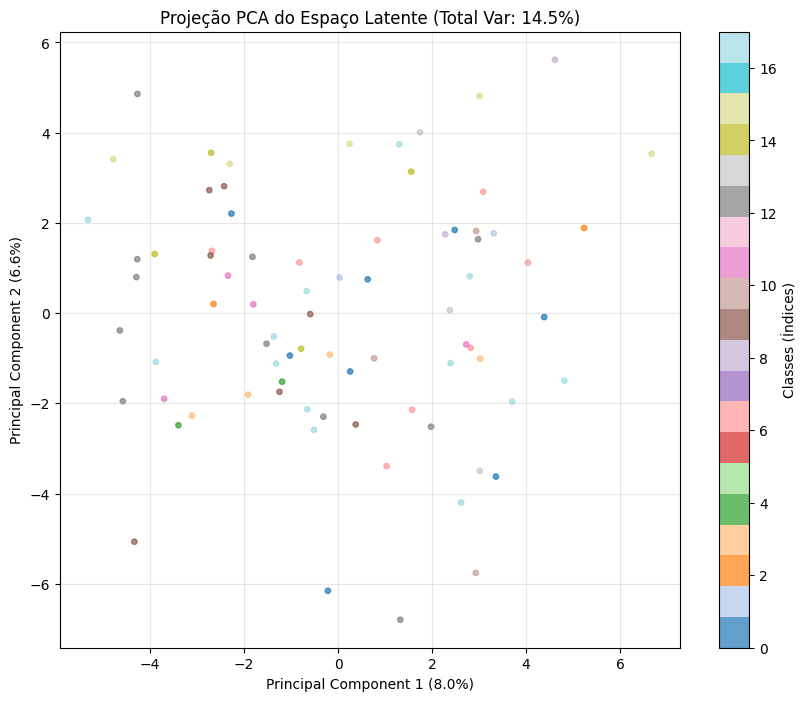


Legenda de Classes:
0: bug
1: dark
2: dragon
3: electric
4: fairy
5: fighting
6: fire
7: flying
8: ghost
9: grass
10: ground
11: ice
12: normal
13: poison
14: psychic
15: rock
16: steel
17: water


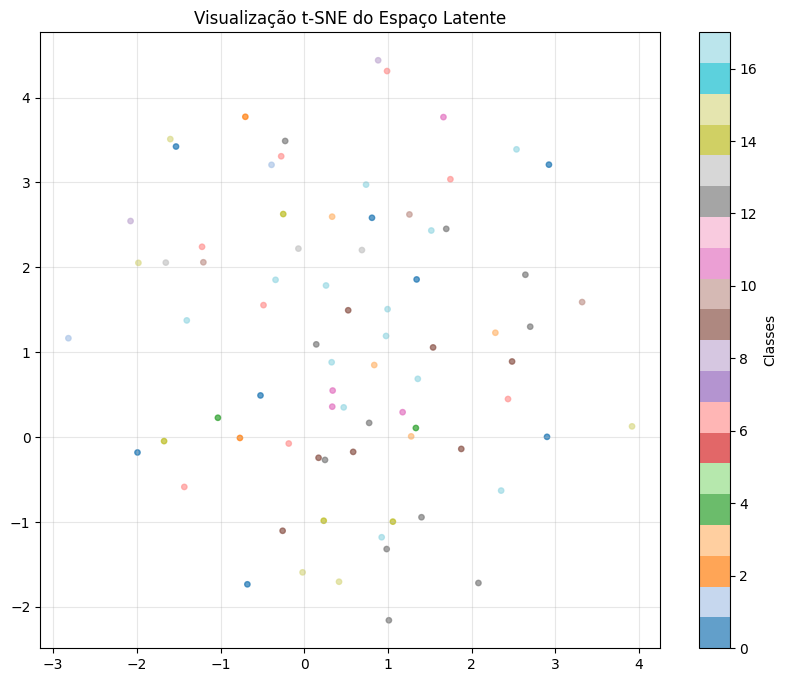

In [5]:
DEVICE = "cuda"
LATENT_DIMS = 128
HIDDEN_DIMS = [32, 64, 128, 256] # Aumentando a profundidade progressivamente
IMAGE_SHAPE = (3, 64, 64) # (Canais, Altura, Largura)
BATCH_SIZE = 32
LR = 0.001 
EPOCHS = 50

lbl_path = "./db/pokemons_labels.csv"
img_path = "./db/pokemon"
transform = transforms.Compose([
    transforms.Resize((IMAGE_SHAPE[1], IMAGE_SHAPE[2])), # Garante que todas tenham o mesmo tamanho
    transforms.ToTensor(), # Converte imagem [0-255] para Tensor [0-1]
])

# --- 1. Carregamento dos dados ---
train_loader, val_loader, test_loader = loadData(lbl_path, img_path, transform, BATCH_SIZE)\
    
# --- 2. Instanciação do modelo ---
vae = VAEmodel(LATENT_DIMS, HIDDEN_DIMS, IMAGE_SHAPE).to(DEVICE)

# --- 3. Definição do otimizador ---
optimizer = torch.optim.Adam(vae.parameters(), lr=LR)

# --- 4. Loop de treinamento e validação ---
best_val_loss = float('inf')
    
print("--- FASE DE TREINAMENTO ----")
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
        
    # --- 1. Treino ---
    train_loss = trainEpoch(vae, train_loader, optimizer, DEVICE)
        
    # --- 2. Validação ---
    val_loss = validateEpoch(vae, val_loader, DEVICE)
        
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
    # Salvar o melhor modelo baseado na validação
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(vae.state_dict(), 'best_vae_model.pth')
        print("-> Modelo salvo (Melhor loss de validação)")
        
# --- 5. Fase de teste do modelo ---
print("--- FASE DE TESTE ----")
try:
    class_names = train_loader.dataset.dataset.classes 
except AttributeError:
    class_names = None # Caso não consiga recuperar os nomes automaticamente
z_test, labels_test = testModel(vae, test_loader, DEVICE)
visualize_latent_space_pca(z_test, labels_test, class_names)
visualize_latent_space_tsne(z_test, labels_test, class_names)

# Modelo 2


Epoch 1/50
--- FASE DE TREINAMENTO ----
Train Loss: 5513.1396 | Val Loss: 5114.2241
-> Modelo salvo (Melhor loss de validação)

Epoch 2/50
--- FASE DE TREINAMENTO ----
Train Loss: 4550.9700 | Val Loss: 4457.6916
-> Modelo salvo (Melhor loss de validação)

Epoch 3/50
--- FASE DE TREINAMENTO ----
Train Loss: 4312.5138 | Val Loss: 4357.5063
-> Modelo salvo (Melhor loss de validação)

Epoch 4/50
--- FASE DE TREINAMENTO ----
Train Loss: 4254.9052 | Val Loss: 4303.7197
-> Modelo salvo (Melhor loss de validação)

Epoch 5/50
--- FASE DE TREINAMENTO ----
Train Loss: 4198.3255 | Val Loss: 4258.4603
-> Modelo salvo (Melhor loss de validação)

Epoch 6/50
--- FASE DE TREINAMENTO ----
Train Loss: 4156.6520 | Val Loss: 4207.8957
-> Modelo salvo (Melhor loss de validação)

Epoch 7/50
--- FASE DE TREINAMENTO ----
Train Loss: 4059.9869 | Val Loss: 4153.6641
-> Modelo salvo (Melhor loss de validação)

Epoch 8/50
--- FASE DE TREINAMENTO ----
Train Loss: 4085.8672 | Val Loss: 4110.4653
-> Modelo salvo (Me

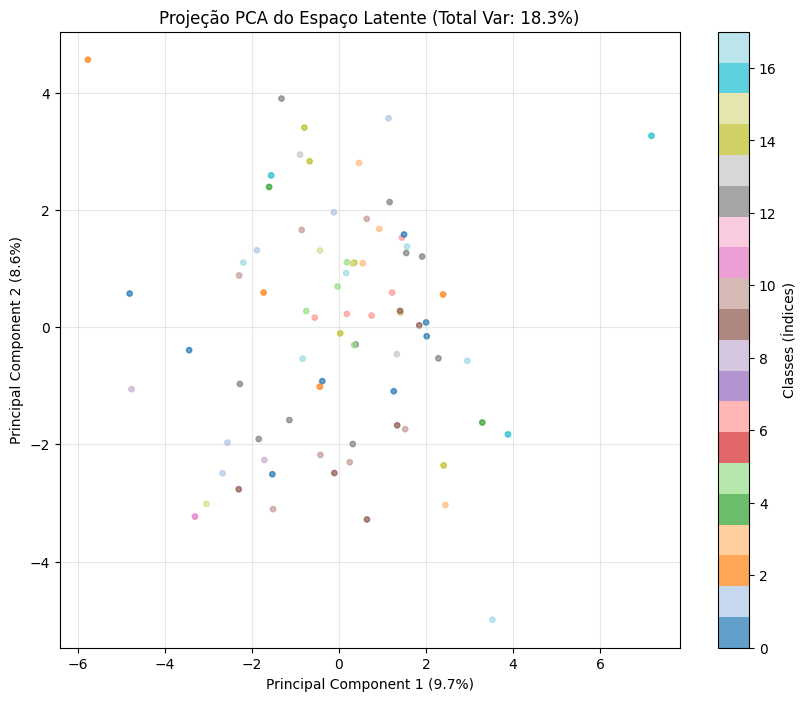


Legenda de Classes:
0: bug
1: dark
2: dragon
3: electric
4: fairy
5: fighting
6: fire
7: flying
8: ghost
9: grass
10: ground
11: ice
12: normal
13: poison
14: psychic
15: rock
16: steel
17: water


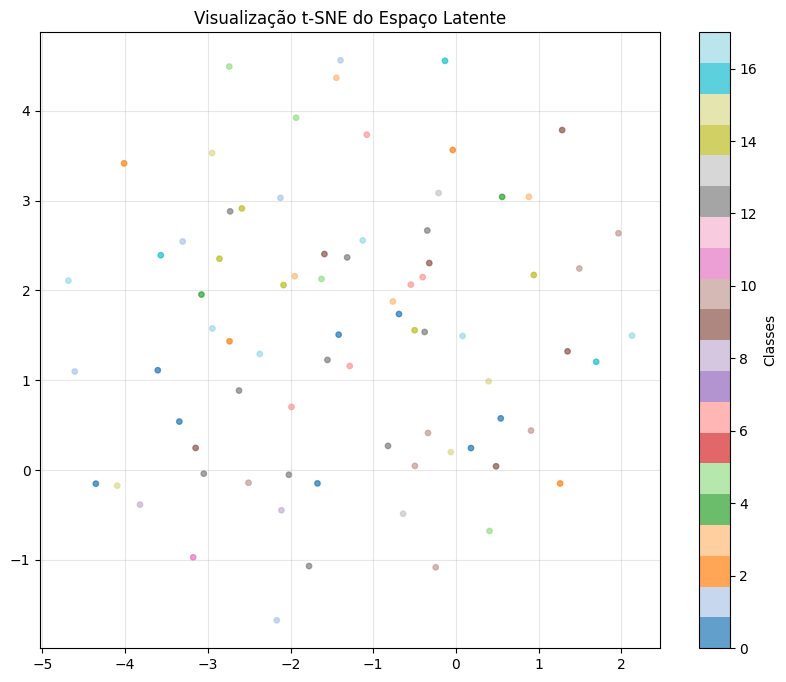

In [6]:
DEVICE = "cuda"
LATENT_DIMS = 32
HIDDEN_DIMS = [64, 128, 256, 512] # Aumentando a profundidade progressivamente
IMAGE_SHAPE = (3, 64, 64) # (Canais, Altura, Largura)
BATCH_SIZE = 32
LR = 0.001 
EPOCHS = 50

lbl_path = "./db/pokemons_labels.csv"
img_path = "./db/pokemon"
transform = transforms.Compose([
    transforms.Resize((IMAGE_SHAPE[1], IMAGE_SHAPE[2])), # Garante que todas tenham o mesmo tamanho
    transforms.ToTensor(), # Converte imagem [0-255] para Tensor [0-1]
])

# --- 1. Carregamento dos dados ---
train_loader, val_loader, test_loader = loadData(lbl_path, img_path, transform, BATCH_SIZE)\
    
# --- 2. Instanciação do modelo ---
vae = VAEmodel(LATENT_DIMS, HIDDEN_DIMS, IMAGE_SHAPE).to(DEVICE)

# --- 3. Definição do otimizador ---
optimizer = torch.optim.Adam(vae.parameters(), lr=LR)

# --- 4. Loop de treinamento e validação ---
best_val_loss = float('inf')
    
print("--- FASE DE TREINAMENTO ----")
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
        
    # --- 1. Treino ---
    train_loss = trainEpoch(vae, train_loader, optimizer, DEVICE)
        
    # --- 2. Validação ---
    val_loss = validateEpoch(vae, val_loader, DEVICE)
        
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
    # Salvar o melhor modelo baseado na validação
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(vae.state_dict(), 'best_vae_model.pth')
        print("-> Modelo salvo (Melhor loss de validação)")
        
# --- 5. Fase de teste do modelo ---
print("--- FASE DE TESTE ----")
try:
    class_names = train_loader.dataset.dataset.classes 
except AttributeError:
    class_names = None # Caso não consiga recuperar os nomes automaticamente
z_test, labels_test = testModel(vae, test_loader, DEVICE)
visualize_latent_space_pca(z_test, labels_test, class_names)
visualize_latent_space_tsne(z_test, labels_test, class_names)